# MarketScout: Система прогнозування цін на авто
Цей ноутбук призначений для побудови моделі машинного навчання, яка прогнозує вартість автомобілів на основі їхніх характеристик.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error, r2_score
import joblib

In [16]:
# Завантаження датасету
data = pd.read_csv("../data/cars_dataset.csv")
df = data.copy()

display(df.head(3))

,ID,Mark,Model,Year,Price_USD,Mileage,Engine,Fuel,Gearbox
0,2059468,Opel,Omega,1990,1900,300,0,"Бензин, 1.8 л.",Ручна / Механіка
1,39346065,Mercedes-Benz,eVito,2021,27800,257,0,Електро,Автомат
2,38511410,Volkswagen,E-Tharu,2020,18000,31,0,Електро,Автомат


In [17]:
# 1. Базове очищення
df = df.drop(columns=['ID', 'Engine'], errors='ignore')
df = df[df['Price_USD'] > 0].copy()

In [18]:
# 2. Створення ознаки Age та фільтрація дуже старих авто
df['Age'] = 2026 - df['Year']
df = df[df['Age'] <= 46].copy() # Відкидаємо авто до 1980 року

In [19]:
# 3. Розбиття Fuel на Fuel_Type та Engine_Capacity
split_data = df['Fuel'].str.split(', ', expand=True)
df['Fuel_Type'] = split_data[0]
df['Engine_Capacity'] = pd.to_numeric(split_data[1].str.replace(' л.', ''), errors='coerce').fillna(0)
df = df.drop(columns=['Fuel'], errors='ignore')

In [20]:
# 4. Створення нових ознак
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)

In [21]:
# 5. Заповнення пропусків
df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')

In [22]:
# 6. Жорсткі бізнес-фільтри (застосовуємо до всього датасету)
df = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 250000) &
    (df['Engine_Capacity'] <= 10)
].copy()

# Підготовка до моделювання

In [23]:
features = ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage']
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']

X = df[features]
y = df['Price_USD']

In [24]:
y_log = np.log1p(y)

# Розбиття на train та test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

In [25]:
# 1. Фільтрація рідкісних марок/моделей
mark_counts = X_train['Mark'].value_counts()
model_counts = X_train['Model'].value_counts()

valid_marks = mark_counts[mark_counts >= 5].index
valid_models = model_counts[model_counts >= 5].index

In [26]:
X_train['Mark'] = np.where(X_train['Mark'].isin(valid_marks), X_train['Mark'], 'Other')
X_train['Model'] = np.where(X_train['Model'].isin(valid_models), X_train['Model'], 'Other')
X_test['Mark'] = np.where(X_test['Mark'].isin(valid_marks), X_test['Mark'], 'Other')
X_test['Model'] = np.where(X_test['Model'].isin(valid_models), X_test['Model'], 'Other')

In [27]:
# 2. Видалення статистичних викидів (Outliers) за допомогою IQR
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [28]:
# Залишаємо лише ті рядки в train, які входять у межі
train_mask = (y_train >= lower_bound) & (y_train <= upper_bound)
X_train = X_train[train_mask]
y_train = y_train[train_mask]

# Навчання моделі CatBoost

In [29]:
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=10,
    l2_leaf_reg=3,
    random_seed=42,
    eval_metric='MAE',
    verbose=500,
    one_hot_max_size=2000
)

print("Починаємо навчання моделі...")
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=150
)

Починаємо навчання моделі...
0:	learn: 0.6181444	test: 0.6519582	best: 0.6519582 (0)	total: 153ms	remaining: 7m 38s
500:	learn: 0.1821495	test: 0.2082415	best: 0.2082415 (500)	total: 8.95s	remaining: 44.7s
1000:	learn: 0.1581055	test: 0.1949821	best: 0.1949821 (1000)	total: 17.5s	remaining: 34.9s
1500:	learn: 0.1437903	test: 0.1891903	best: 0.1891903 (1500)	total: 26.1s	remaining: 26s
2000:	learn: 0.1325423	test: 0.1862620	best: 0.1862601 (1998)	total: 34.6s	remaining: 17.3s
2500:	learn: 0.1235178	test: 0.1842000	best: 0.1842000 (2500)	total: 43.4s	remaining: 8.67s
2999:	learn: 0.1163725	test: 0.1830861	best: 0.1830861 (2999)	total: 52.3s	remaining: 0us

bestTest = 0.1830860839
bestIteration = 2999



CatBoostRegressor(depth=10, eval_metric='MAE', iterations=3000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', one_hot_max_size=2000, random_seed=42, verbose=500)

In [30]:
# Отримуємо прогнози
y_pred_log = model.predict(X_test)

# Повертаємо ціни у звичайні долари за допомогою експоненти
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print(f"\n--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---")
print(f"MAE (Середня похибка в доларах): {mean_absolute_error(y_test_real, y_pred):.2f} USD")
print(f"MAPE (Середня похибка у відсотках): {mean_absolute_percentage_error(y_test_real, y_pred)*100:.2f}%")
print(f"R2_score: {r2_score(y_test_real, y_pred):.4f}")


--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---
MAE (Середня похибка в доларах): 3166.87 USD
MAPE (Середня похибка у відсотках): 21.05%
R2_score: 0.8545


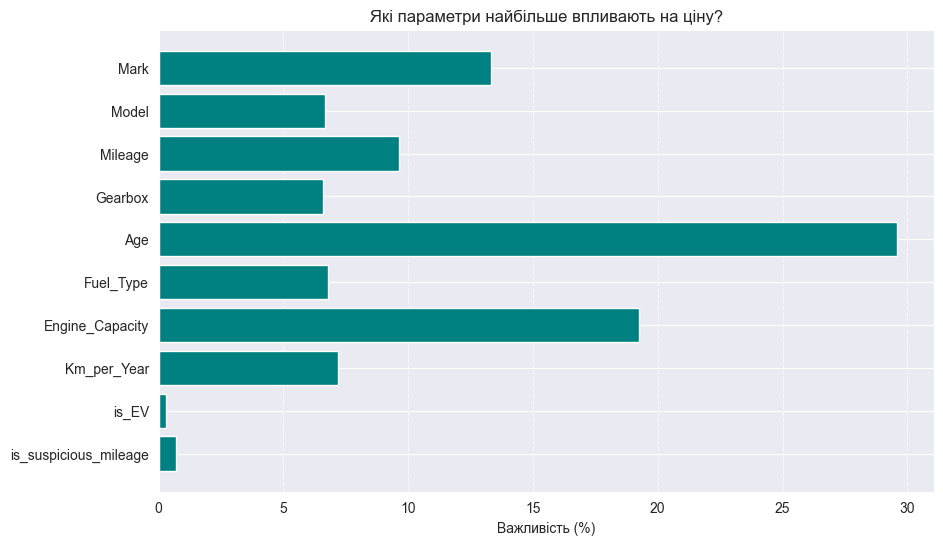

In [31]:
importance = model.get_feature_importance()

plt.figure(figsize=(10, 6))
plt.barh(features, importance, color='teal')
plt.xlabel('Важливість (%)')
plt.title('Які параметри найбільше впливають на ціну?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()